# 01 — Data Generation

This notebook walks through how synthetic students and schools are created for
the lottery-based school assignment simulation.

**Topics covered**
- `Student` and `School` struct definitions
- Weighted preference sampling (Efraimidis–Spirakis)
- Configurable scenario generation
- Summary statistics and basic visualisation of the generated data

In [2]:
# Activate the project environment
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

  Activating project at `~/Documents/MIT/18.337/parallel-school-assignment-sim`


In [3]:
# Load source modules
include("../src/types.jl")
include("../src/generate_data.jl")

using Random, Statistics

## 1. Generate a Scenario

Use `generate_scenario` for a reproducible setup with the default parameters:
10,000 students, 20 schools, top-5 preferences.

In [4]:
students, schools = generate_scenario(;
    n_students  = 10_000,
    n_schools   = 20,
    pref_length = 5,
    seed        = 42,
)

println("Students : ", length(students))
println("Schools  : ", length(schools))
println("First student: ", students[1])

Students : 10000
Schools  : 20
First student: Student(1, [17, 2, 20, 13, 15], 0.5776180399036042)


## 2. School Capacity Distribution

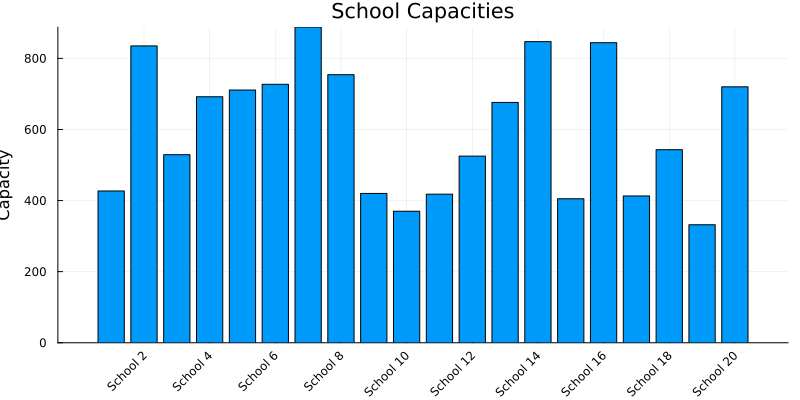

In [5]:
using Plots

capacities = [s.capacity for s in schools]
bar(
    [s.name for s in schools], capacities;
    xlabel    = "School",
    ylabel    = "Capacity",
    title     = "School Capacities",
    xrotation = 45,
    legend    = false,
    size      = (800, 400),
)

## 3. Preference Popularity

Which schools appear most often as the top choice?

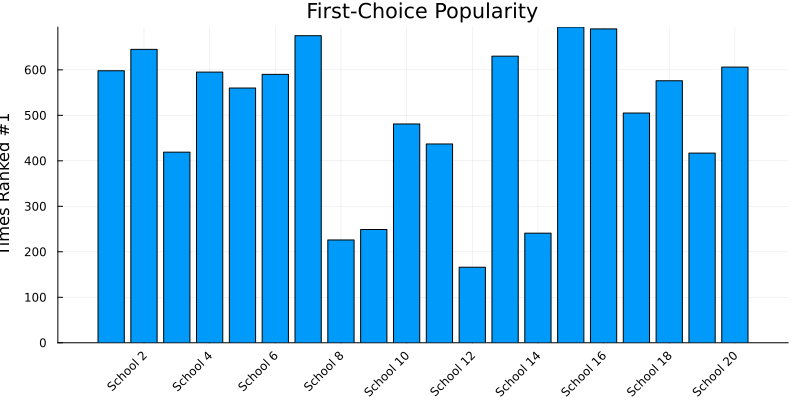

In [6]:
first_choices = [s.preferences[1] for s in students]
counts = [count(==(i), first_choices) for i in 1:length(schools)]

bar(
    ["School $i" for i in 1:length(schools)], counts;
    xlabel    = "School",
    ylabel    = "Times Ranked #1",
    title     = "First-Choice Popularity",
    xrotation = 45,
    legend    = false,
    size      = (800, 400),
)

## 4. Lottery Number Distribution

Lottery numbers should be approximately uniform on [0, 1).

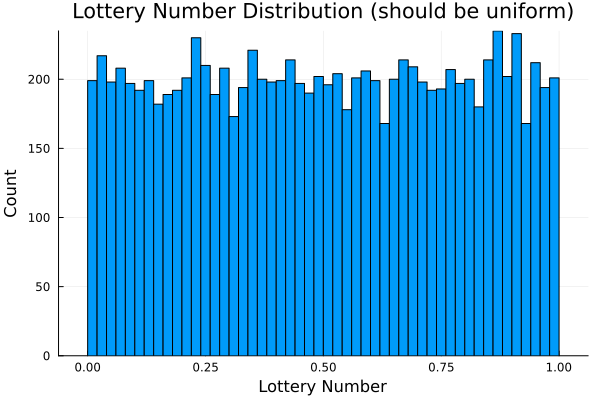

In [7]:
lotteries = [s.lottery_number for s in students]
histogram(
    lotteries;
    bins   = 50,
    xlabel = "Lottery Number",
    ylabel = "Count",
    title  = "Lottery Number Distribution (should be uniform)",
    legend = false,
)